In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import seaborn as sns
from scipy.fft import fft, fftfreq
from pathlib import Path


In [2]:

cwd = Path.cwd()
project_root = cwd if (cwd / "data").exists() else cwd.parent
csv_file = project_root / "data" / "climb_20260625_105842_81af6997.csv"

if not csv_file.exists():
    raise FileNotFoundError(f"CSV not found: {csv_file}")

# Skip metadata section
df = pd.read_csv(
    csv_file,
    sep=",",
    quotechar='"',
    comment="#",
    engine="python"
)

df.columns = [c.strip().strip('"') for c in df.columns]
print(df.head())
print(df["Sensor"].unique())

print("=" * 70)
print("DATA OVERVIEW")
print("=" * 70)
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nDataframe shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:\n{df.describe()}")


   Time(ms) Sensor  Accel.X(m/s²)  Accel.Y(m/s²)  Accel.Z(m/s²)  \
0       102  fused       0.000000       0.000000       0.000000   
1       124  fused      -0.331404       0.300564       9.852358   
2       144  fused      -0.398478       0.870693       9.663114   
3       167  fused      -0.372128       1.347397       9.730187   
4       200  fused      -0.472739       0.501786       9.766120   

   Gyro.X(rad/s)  Gyro.Y(rad/s)  Gyro.Z(rad/s)  Heart(bpm)  Pressure(hPa)  \
0            0.0            0.0            0.0         0.0            0.0   
1            0.0            0.0            0.0         0.0            0.0   
2            0.0            0.0            0.0         0.0            0.0   
3            0.0            0.0            0.0         0.0            0.0   
4            0.0            0.0            0.0         0.0            0.0   

   Altitude(m)  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  
['fused']
DATA OVERVIEW

Column 

,Time(ms),Sensor,Accel.X(m/s²),Accel.Y(m/s²),Accel.Z(m/s²),Gyro.X(rad/s),Gyro.Y(rad/s),Gyro.Z(rad/s),Heart(bpm),Pressure(hPa),Altitude(m)
0,102,fused,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,124,fused,-0.331404,0.300564,9.852358,0.0,0.0,0.0,0.0,0.0,0.0
2,144,fused,-0.398478,0.870693,9.663114,0.0,0.0,0.0,0.0,0.0,0.0
3,167,fused,-0.372128,1.347397,9.730187,0.0,0.0,0.0,0.0,0.0,0.0
4,200,fused,-0.472739,0.501786,9.766120,0.0,0.0,0.0,0.0,0.0,0.0



Data types:
Time(ms)           int64
Sensor            object
Accel.X(m/s²)    float64
Accel.Y(m/s²)    float64
Accel.Z(m/s²)    float64
Gyro.X(rad/s)    float64
Gyro.Y(rad/s)    float64
Gyro.Z(rad/s)    float64
Heart(bpm)       float64
Pressure(hPa)    float64
Altitude(m)      float64
dtype: object

Basic statistics:
           Time(ms)  Accel.X(m/s²)  Accel.Y(m/s²)  Accel.Z(m/s²)  \
count    831.000000     831.000000     831.000000     831.000000   
mean    8405.221420       0.757414      -6.788598       5.082434   
std     4800.854196       1.697049       4.562856       4.151816   
min      102.000000     -27.223288     -37.452515     -41.703594   
25%     4254.500000      -0.270319      -9.760536       2.476613   
50%     8405.000000       1.204111      -8.876596       4.668496   
75%    12555.000000       1.337062      -0.607331       9.346908   
max    16705.000000      12.853428      14.220815      28.379154   

       Gyro.X(rad/s)  Gyro.Y(rad/s)  Gyro.Z(rad/s)  Heart(bpm)  Pr

In [4]:
import matplotlib.pyplot as plt

df = df.sort_values("Time(ms)")
t = df["Time(ms)"] / 1000  # convert to seconds (recommended)

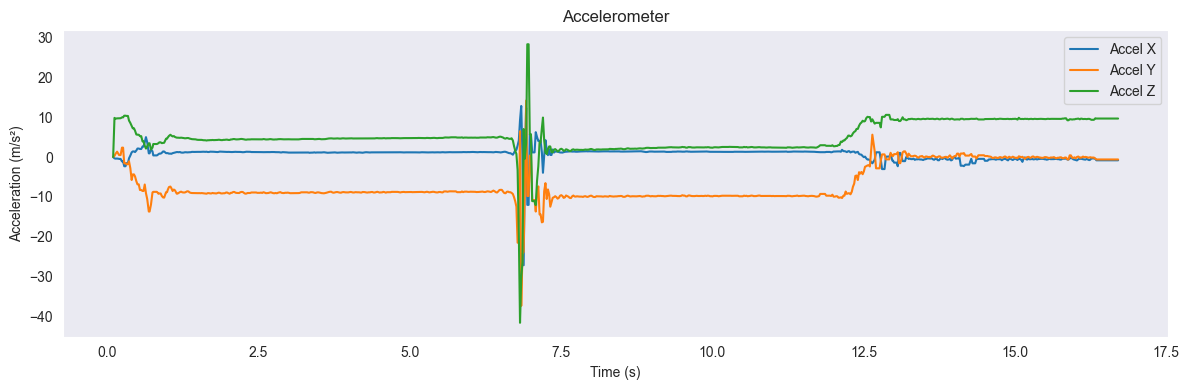

In [5]:
plt.figure(figsize=(12, 4))

plt.plot(t, df["Accel.X(m/s²)"], label="Accel X")
plt.plot(t, df["Accel.Y(m/s²)"], label="Accel Y")
plt.plot(t, df["Accel.Z(m/s²)"], label="Accel Z")

plt.title("Accelerometer")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

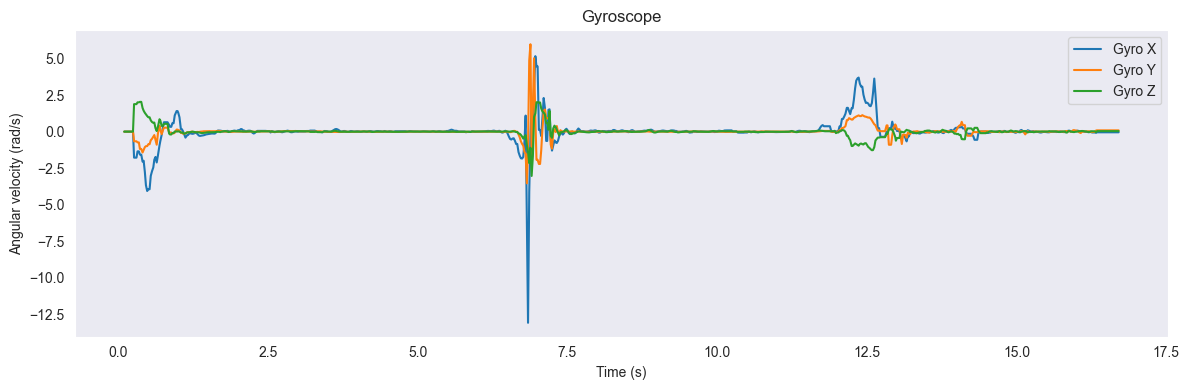

In [6]:
plt.figure(figsize=(12, 4))

plt.plot(t, df["Gyro.X(rad/s)"], label="Gyro X")
plt.plot(t, df["Gyro.Y(rad/s)"], label="Gyro Y")
plt.plot(t, df["Gyro.Z(rad/s)"], label="Gyro Z")

plt.title("Gyroscope")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from scipy.signal import butter, filtfilt

df = df.sort_values("Time(ms)")
t = df["Time(ms)"].values / 1000

acc_mag = np.sqrt(
    df["Accel.X(m/s²)"]**2 +
    df["Accel.Y(m/s²)"]**2 +
    df["Accel.Z(m/s²)"]**2
)

# remove gravity baseline
imu_signal = acc_mag - np.mean(acc_mag)

# smooth (removes tiny noise, keeps motion bursts)
def lowpass(x, cutoff=6, fs=50):
    nyq = 0.5 * fs
    b, a = butter(2, cutoff / nyq, btype="low")
    return filtfilt(b, a, x)

imu_signal = lowpass(imu_signal)